## DATA COLLECTION

In [ ]:
from google.colab import files
files.upload()


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"pooraniayswariyaps","key":"19bed4598ff7aab45cf59c4763d0f7f6"}'}

In [ ]:
import os
import shutil

os.makedirs("/root/.kaggle", exist_ok=True)
shutil.move("kaggle.json", "/root/.kaggle/kaggle.json")

os.chmod("/root/.kaggle/kaggle.json", 600)

print("Kaggle.json configured successfully!")

Kaggle.json configured successfully!


In [ ]:
!pip install kaggle


In [ ]:
!kaggle datasets download -d brjapon/cwru-bearing-datasets

Dataset URL: https://www.kaggle.com/datasets/brjapon/cwru-bearing-datasets
License(s): CC-BY-SA-4.0
  0% 0.00/40.4M [00:00<?, ?B/s]
100% 40.4M/40.4M [00:00<00:00, 1.43GB/s]


In [ ]:
import zipfile

zip_path = "cwru-bearing-datasets.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("CWRU_Dataset")

print("Dataset extracted successfully into CWRU_Dataset folder!")


Dataset extracted successfully into CWRU_Dataset folder!


In [ ]:
import os

for root, dirs, files in os.walk("CWRU_Dataset"):
    for file in files:
        if file.endswith(".mat") or file.endswith(".npz") or file.endswith(".csv"):
            print(os.path.join(root, file))


CWRU_Dataset/CWRU_48k_load_1_CNN_data.npz
CWRU_Dataset/feature_time_48k_2048_load_1.csv
CWRU_Dataset/raw/Time_Normal_1_098.mat
CWRU_Dataset/raw/OR021_6_1_239.mat
CWRU_Dataset/raw/B007_1_123.mat
CWRU_Dataset/raw/OR014_6_1_202.mat
CWRU_Dataset/raw/B021_1_227.mat
CWRU_Dataset/raw/IR014_1_175.mat
CWRU_Dataset/raw/OR007_6_1_136.mat
CWRU_Dataset/raw/IR021_1_214.mat
CWRU_Dataset/raw/B014_1_190.mat
CWRU_Dataset/raw/IR007_1_110.mat


## DATA PREPARATION

**Import Libraries**

In [ ]:
import os
import glob
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization


**Load All .mat Files**

In [ ]:
DATA_PATH = "CWRU_Dataset/raw/*.mat"
mat_files = glob.glob(DATA_PATH)

print("Total .mat files:", len(mat_files))


Total .mat files: 10


**Extract Signal Function**

In [ ]:
def extract_signal_from_mat(file_path):
    mat_data = sio.loadmat(file_path)

    for key in mat_data.keys():
        if "DE_time" in key:
            return mat_data[key].flatten()

    raise ValueError(f"No DE_time signal found in {file_path}")


**Extract Label from Filename**

In [ ]:
def get_label_from_filename(file_path):
    filename = os.path.basename(file_path)

    if "Normal" in filename:
        return "Normal"
    elif filename.startswith("IR"):
        return "IR"
    elif filename.startswith("OR"):
        return "OR"
    elif filename.startswith("B"):
        return "B"
    else:
        return "Unknown"


**Segment Signal**

In [ ]:
def segment_signal(signal, segment_size=2048):
    segments = []
    for i in range(0, len(signal) - segment_size, segment_size):
        segments.append(signal[i:i+segment_size])
    return np.array(segments)


**Create Dataset (X, y)**

In [ ]:
X = []
y = []

SEGMENT_SIZE = 2048

for file in mat_files:
    signal = extract_signal_from_mat(file)
    label = get_label_from_filename(file)

    if label == "Unknown":
        continue

    segments = segment_signal(signal, SEGMENT_SIZE)

    for seg in segments:
        X.append(seg)
        y.append(label)

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)  # (samples, 2048)
print("y shape:", y.shape)
print("Classes:", np.unique(y))


X shape: (2369, 2048)
y shape: (2369,)
Classes: ['B' 'IR' 'Normal' 'OR']


## DATA PRE-PROCESSING

**Encode Labels**

In [ ]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Class labels:", label_encoder.classes_)


Class labels: ['B' 'IR' 'Normal' 'OR']


**Reshape X for CNN Input**

In [ ]:
X = X.reshape(X.shape[0], X.shape[1], 1)

print("Reshaped X:", X.shape)


Reshaped X: (2369, 2048, 1)


**Train-Test Split**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Train:", X_train.shape)
print("Test :", X_test.shape)


Train: (1895, 2048, 1)
Test : (474, 2048, 1)


## MODEL BUILDING [1D CNN]

In [ ]:
from tensorflow.keras.optimizers import Adam


In [ ]:
cnn_model = Sequential([
    Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(SEGMENT_SIZE, 1)),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),

    Conv1D(filters=128, kernel_size=3, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),

    Conv1D(filters=256, kernel_size=3, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),

    Conv1D(filters=512, kernel_size=3, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.2),

    Dense(len(label_encoder.classes_), activation='softmax')
])

cnn_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


cnn_model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 2046, 64)       │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 2046, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 1023, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 1021, 128)      │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1021, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 510, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 508, 256)       │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 508, 256)       │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 254, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 252, 512)       │       393,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 252, 512)       │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 126, 512)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 64512)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     8,257,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,779,268 (33.49 MB)

 Trainable params: 8,777,348 (33.48 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [ ]:
history = cnn_model.fit(
    X_train, y_train,
    epochs=15,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)


Epoch 1/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 65s 1s/step - accuracy: 0.6808 - loss: 1.0066 - val_accuracy: 0.0844 - val_loss: 6.2136
Epoch 2/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.9323 - loss: 0.2040 - val_accuracy: 0.0844 - val_loss: 7.5833
Epoch 3/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 60s 1s/step - accuracy: 0.9649 - loss: 0.0811 - val_accuracy: 0.3377 - val_loss: 7.2609
Epoch 4/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 83s 1s/step - accuracy: 0.9893 - loss: 0.0465 - val_accuracy: 0.3272 - val_loss: 8.1896
Epoch 5/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - accuracy: 0.9794 - loss: 0.0527 - val_accuracy: 0.3272 - val_loss: 10.4596
Epoch 6/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - accuracy: 0.9887 - loss: 0.0363 - val_accuracy: 0.3272 - val_loss: 13.6890
Epoch 7/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 85s 1s/step - accuracy: 0.9964 - loss: 0.0201 - val_accuracy: 0.3272 - val_loss: 12.5018
Epoch 8/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 79s 1s/step - accuracy: 0.9914 - loss: 0.0372 - val_accuracy: 0.3641 - val_lo

In [ ]:
test_loss, test_acc = cnn_model.evaluate(X_test, y_test)
print("Test Accuracy:", test_acc)


15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 231ms/step - accuracy: 0.8976 - loss: 0.6030
Test Accuracy: 0.8902953863143921


In [ ]:
y_pred_probs = cnn_model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

print(classification_report(
    y_test, y_pred,
    target_names=label_encoder.classes_
))


15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 279ms/step
              precision    recall  f1-score   support

           B       0.73      1.00      0.85       142
          IR       1.00      1.00      1.00       142
      Normal       1.00      1.00      1.00        47
          OR       1.00      0.64      0.78       143

    accuracy                           0.89       474
   macro avg       0.93      0.91      0.91       474
weighted avg       0.92      0.89      0.89       474



<Figure size 700x600 with 0 Axes>

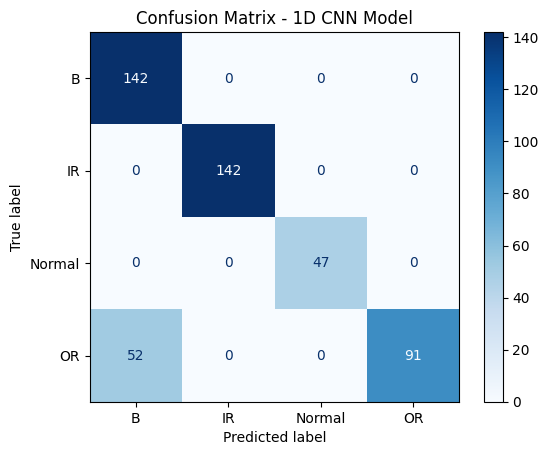

In [ ]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)

plt.figure(figsize=(7,6))
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix - 1D CNN Model")
plt.show()


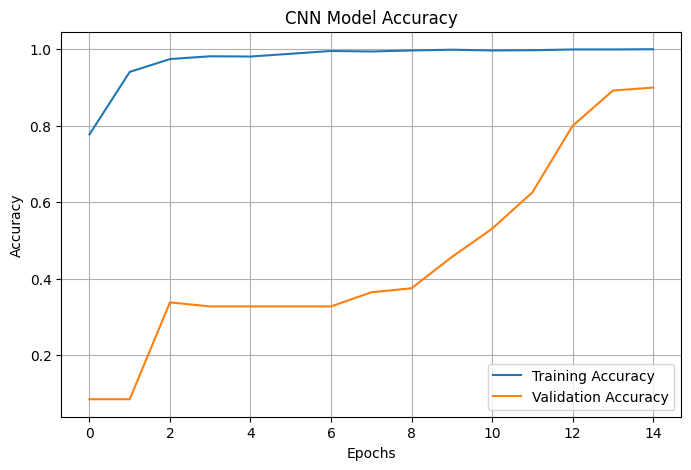

In [ ]:
import matplotlib.pyplot as plt

# Accuracy Plot
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("CNN Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
cnn_model.save("CNN_CWRU_model.keras")
print("CNN model saved successfully!")


CNN model saved successfully!
